**STEP 01 IMPORT LIBRARIES**

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

**STEP 2 LOAD DATASET**

In [4]:
import pandas as pd
df = pd.read_csv("engineered_accessibility_dataset.csv")

**STEP 03 SELECT FEATURES**

In [5]:
y = df["Accessibility_Score"]

# Remove Target Columns
X = df.drop(columns=[
    "Accessibility_Score",
    "Accessibility_Category",
    "Improvement_Priority"
])

**STEP 04 TRAIN THE SPLIT**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**STEP 05 FUNCTION FOR EVALUATION**

In [7]:
# 1. Import all required metrics and libraries
# import numpy as np
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from sklearn.linear_model import LinearRegression

# 2. Define the evaluation function (Your existing function)
def evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)
    mse = mean_squared_error(y_test, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, prediction)

    print("\n" + "*" * 50)
    print(model_name)
    print("*" * 50)
    print(f"MAE : {round(mae, 3)}")
    print(f"RMSE : {round(rmse, 3)}")
    print(f"R\u00b2 Score : {round(r2, 3)}")
    print()

# 3. Create the model instance
model = LinearRegression()

# Store original X_train and X_test for temporary modification
_original_X_train_temp = X_train.copy()
_original_X_test_temp = X_test.copy()

# Identify non-numeric columns (e.g., 'object' dtype) in X_train
columns_to_drop = X_train.select_dtypes(include=['object']).columns.tolist()

# Temporarily drop non-numeric columns from X_train and X_test
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

# 4. Call the function to display the output
evaluate_model(model, "Linear Regression Model")

# Restore original X_train and X_test to their previous state
X_train = _original_X_train_temp
X_test = _original_X_test_temp


**************************************************
Linear Regression Model
**************************************************
MAE : 6.451
RMSE : 8.19
R² Score : 0.889



**STEP 6 LINEAR REGRESSION**

In [8]:
# Store original X_train and X_test for potential later use if other models require them
_original_X_train = X_train.copy()
_original_X_test = X_test.copy()

# Identify non-numeric columns (e.g., 'object' dtype) in X_train
# Using select_dtypes to dynamically find all non-numeric columns
columns_to_drop = X_train.select_dtypes(include=['object']).columns.tolist()

# Temporarily modify the global X_train and X_test to only include numeric columns
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

linear = LinearRegression()

evaluate_model(
    linear,
    "Linear Regression"
)

# Restore original X_train and X_test to their previous state
X_train = _original_X_train
X_test = _original_X_test


**************************************************
Linear Regression
**************************************************
MAE : 6.451
RMSE : 8.19
R² Score : 0.889



**STEP 07 DECISION TREE**

In [9]:
# Store original X_train and X_test for temporary modification
_original_X_train_temp = X_train.copy()
_original_X_test_temp = X_test.copy()

# Identify non-numeric columns (e.g., 'object' dtype) in X_train
columns_to_drop = X_train.select_dtypes(include=['object']).columns.tolist()

# Temporarily drop non-numeric columns from X_train and X_test
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

tree = DecisionTreeRegressor(
    random_state=42 # Fixed typo here
)

evaluate_model(
    tree,
    "Decision Tree"
)

# Restore original X_train and X_test to their previous state
X_train = _original_X_train_temp
X_test = _original_X_test_temp


**************************************************
Decision Tree
**************************************************
MAE : 9.182
RMSE : 12.476
R² Score : 0.743



**STEP 08 RANDOM FOREST**

In [10]:
forest = RandomForestRegressor(
    random_state=42
)

# Store original X_train and X_test for temporary modification
_original_X_train_temp = X_train.copy()
_original_X_test_temp = X_test.copy()

# Identify non-numeric columns (e.g., 'object' dtype) in X_train
columns_to_drop = X_train.select_dtypes(include=['object']).columns.tolist()

# Temporarily drop non-numeric columns from X_train and X_test
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

evaluate_model(
    forest,
    "Random Forest"
)

# Restore original X_train and X_test to their previous state
X_train = _original_X_train_temp
X_test = _original_X_test_temp


**************************************************
Random Forest
**************************************************
MAE : 6.482
RMSE : 8.121
R² Score : 0.891



**STEP 09 SUPPORT VECTOR REGRESSION**

In [11]:
svr = SVR()

# Store original X_train and X_test for temporary modification
_original_X_train_temp = X_train.copy()
_original_X_test_temp = X_test.copy()

# Identify non-numeric columns (e.g., 'object' dtype) in X_train
columns_to_drop = X_train.select_dtypes(include=['object']).columns.tolist()

# Temporarily drop non-numeric columns from X_train and X_test
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

evaluate_model(
    svr,
    "Support Vector Regression"
)

# Restore original X_train and X_test to their previous state
X_train = _original_X_train_temp
X_test = _original_X_test_temp


**************************************************
Support Vector Regression
**************************************************
MAE : 17.429
RMSE : 21.787
R² Score : 0.216



**STEP 10 XGBOOST**

In [12]:
xgb = XGBRegressor(
    random_state=42
)

# Store original X_train and X_test for temporary modification
_original_X_train_temp = X_train.copy()
_original_X_test_temp = X_test.copy()

# Identify non-numeric columns (e.g., 'object' dtype) in X_train
columns_to_drop = X_train.select_dtypes(include=['object']).columns.tolist()

# Temporarily drop non-numeric columns from X_train and X_test
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

evaluate_model(
    xgb,
    "XGBoost"
)

# Restore original X_train and X_test to their previous state
X_train = _original_X_train_temp
X_test = _original_X_test_temp


**************************************************
XGBoost
**************************************************
MAE : 5.084
RMSE : 6.418
R² Score : 0.932



**STEP 11 K-FOLD CROSS VALIDATION**

In [13]:
models = {

    "Linear Regression":LinearRegression(),
    "Decision Tree":DecisionTreeRegressor(random_state=42),
    "Random Forest":RandomForestRegressor(random_state=42),
    "SVR":SVR(),
    "XGBoost":XGBRegressor(random_state=42)
}
# Identify non-numeric columns (e.g., 'object' dtype) in X
columns_to_drop_cv = X.select_dtypes(include=['object']).columns.tolist()

# Create a temporary X for cross-validation by dropping non-numeric columns
X_numeric_cv = X.drop(columns=columns_to_drop_cv, errors='ignore')
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_numeric_cv, # Use the numeric version of X
        y,
        cv=5,
        scoring="r2"
    )
    print(name)
    print("Average R² :", round(scores.mean(),3))
    print("-------------------------")

Linear Regression
Average R² : 0.887
-------------------------
Decision Tree
Average R² : 0.687
-------------------------
Random Forest
Average R² : 0.875
-------------------------
SVR
Average R² : 0.171
-------------------------
XGBoost
Average R² : 0.922
-------------------------


**STEP 12 MODEL COMPARISION**

In [14]:
results = []

# Identify non-numeric columns (e.g., 'object' dtype) in X_train
columns_to_drop_train_test = X_train.select_dtypes(include=['object']).columns.tolist()

# Create numerical versions of X_train and X_test for this loop
X_train_numeric = X_train.drop(columns=columns_to_drop_train_test, errors='ignore')
X_test_numeric = X_test.drop(columns=columns_to_drop_train_test, errors='ignore')

for name, model in models.items():

    model.fit(X_train_numeric, y_train)

    prediction = model.predict(X_test_numeric)

    results.append({

        "Model":name,

        "MAE":mean_absolute_error(y_test,prediction),

        "RMSE":np.sqrt(mean_squared_error(y_test,prediction)),

        "R²":r2_score(y_test,prediction)

    })

comparison = pd.DataFrame(results)

comparison.sort_values(
    by="R²",
    ascending=False
)

,Model,MAE,RMSE,R²
4,XGBoost,5.083562,6.418299,0.932000
2,Random Forest,6.481815,8.120685,0.891143
0,Linear Regression,6.450699,8.189849,0.889281
1,Decision Tree,9.181500,12.475562,0.743085
3,SVR,17.429008,21.786982,0.216455


**VISUALIZATION**

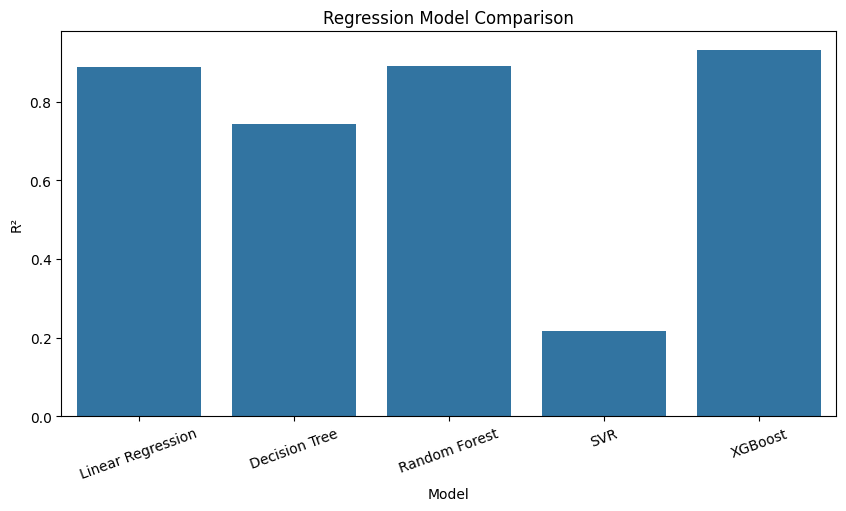

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="R²",
    data=comparison
)

plt.title("Regression Model Comparison")
plt.xticks(rotation=20)
plt.show()

**STEP 14 FEATURE IMPORTANCE**

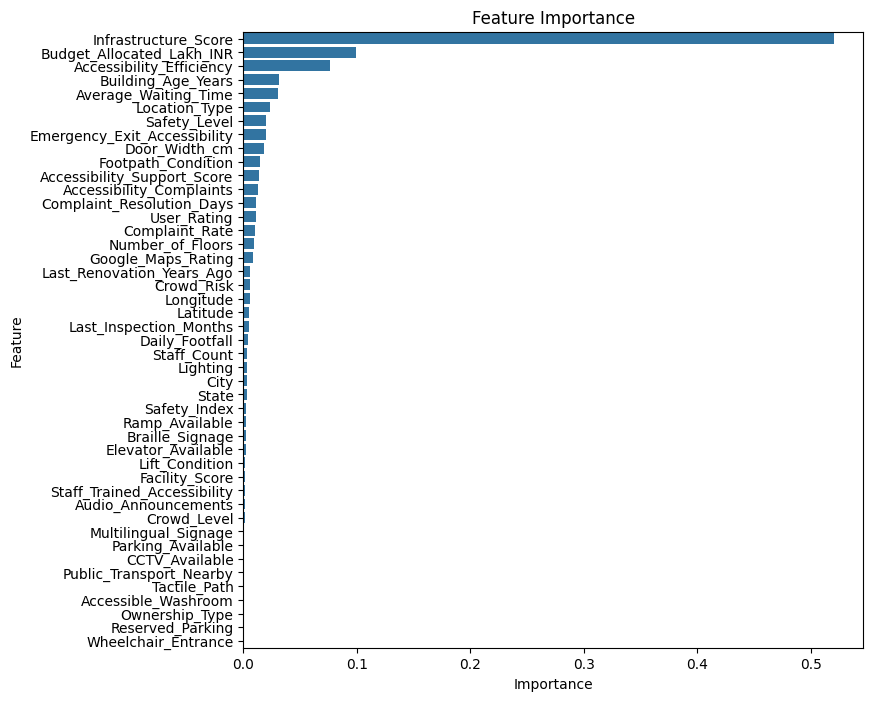

In [16]:
columns_to_drop_importance = X.select_dtypes(include=['object']).columns.tolist()
X_numeric_for_importance = X.drop(columns=columns_to_drop_importance, errors='ignore')

importance = pd.DataFrame({
    "Feature":X_numeric_for_importance.columns,
    "Importance":forest.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)
plt.title("Feature Importance")
plt.show()

**STEP 15 SAVE BEST MODEL**

In [17]:
import joblib

joblib.dump(
    forest,
    "best_regression_model.pkl"
)

['best_regression_model.pkl']